# Imports

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

# Data Preperation for time-dependence

In [62]:
charging_data = pd.read_csv("../00_Productive_Data/charging_data_clean.csv", parse_dates=["connectionTime","disconnectTime","doneChargingTime"])
charging_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60922 entries, 0 to 60921
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        60922 non-null  int64  
 1   id                60922 non-null  object 
 2   connectionTime    60922 non-null  object 
 3   disconnectTime    60922 non-null  object 
 4   doneChargingTime  60922 non-null  object 
 5   kWhDelivered      60922 non-null  float64
 6   sessionID         60922 non-null  object 
 7   siteID            60922 non-null  int64  
 8   spaceID           60922 non-null  object 
 9   timezone          60922 non-null  object 
 10  userID            44637 non-null  float64
 11  userInputs        44637 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 5.6+ MB


In [63]:
date_columns = ["connectionTime", "disconnectTime", "doneChargingTime"]

for data in date_columns:
    charging_data[data] = pd.to_datetime(charging_data[data], utc=True)

def convert_to_local(row): 
    tz = row["timezone"]
    for col in date_columns:
        ts = row[col]
        if pd.isna(ts):
            continue 
        row[col] = ts.tz_convert(tz)
    return row 

charging_data = charging_data.apply(convert_to_local, axis=1)

charging_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60922 entries, 0 to 60921
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   Unnamed: 0        60922 non-null  int64                              
 1   id                60922 non-null  object                             
 2   connectionTime    60922 non-null  datetime64[ns, America/Los_Angeles]
 3   disconnectTime    60922 non-null  datetime64[ns, America/Los_Angeles]
 4   doneChargingTime  60922 non-null  datetime64[ns, America/Los_Angeles]
 5   kWhDelivered      60922 non-null  float64                            
 6   sessionID         60922 non-null  object                             
 7   siteID            60922 non-null  int64                              
 8   spaceID           60922 non-null  object                             
 9   timezone          60922 non-null  object                     

In [64]:
# überlegen ob es vielleicht auch ohne lambda eleganter geht
charging_data["year"] = charging_data["connectionTime"].map(lambda x: x.year)
charging_data["month"] = charging_data["connectionTime"].map(lambda x: x.month)
charging_data["weekday"] = charging_data["connectionTime"].map(lambda x: x.weekday())
charging_data["connectionHour"] = charging_data["connectionTime"].map(lambda x: x.hour)
charging_data["disconnectionHour"] = charging_data["disconnectTime"].map(lambda x: x.hour)

charging_data["chargingDuration"] = (charging_data["doneChargingTime"] - charging_data["connectionTime"]).dt.total_seconds() / 3600
charging_data["connectionDuration"] = (charging_data["disconnectTime"] - charging_data["connectionTime"]).dt.total_seconds() / 3600
charging_data["chargingEfficiency"] = charging_data["chargingDuration"]/charging_data["connectionDuration"]


charging_data.head()

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,timezone,userID,userInputs,year,month,weekday,connectionHour,disconnectionHour,chargingDuration,connectionDuration,chargingEfficiency
0,52871,5c36631ef9af8b4639a8e5bc,2018-10-08 15:44:47-07:00,2018-10-08 17:59:14-07:00,2018-10-08 17:56:20-07:00,10.208,1_1_193_825_2018-10-08 22:44:47.505042,1,AG-1F01,America/Los_Angeles,NaN,NaN,2018,10,0,15,17,2.192500,2.240833,0.978431
1,52886,5c366352f9af8b4639a8e5cb,2018-10-09 06:08:55-07:00,2018-10-09 15:03:56-07:00,2018-10-09 10:33:24-07:00,11.837,1_1_193_825_2018-10-09 13:08:55.279362,1,AG-1F01,America/Los_Angeles,NaN,NaN,2018,10,1,6,15,4.408056,8.916944,0.494346
2,52942,5c366352f9af8b4639a8e603,2018-10-09 15:26:40-07:00,2018-10-09 19:48:12-07:00,2018-10-09 19:28:29-07:00,12.034,1_1_193_825_2018-10-09 22:26:39.626134,1,AG-1F01,America/Los_Angeles,383.0,"[{'WhPerMile': 400, 'kWhRequested': 15.2, 'mil...",2018,10,1,15,19,4.030278,4.358889,0.924611
3,52958,5c36639ff9af8b4639a8e613,2018-10-10 06:15:02-07:00,2018-10-10 15:30:44-07:00,2018-10-10 10:56:11-07:00,11.985,1_1_193_825_2018-10-10 13:15:01.608497,1,AG-1F01,America/Los_Angeles,NaN,NaN,2018,10,2,6,15,4.685833,9.261667,0.505938
4,53015,5c36639ff9af8b4639a8e64c,2018-10-10 15:52:56-07:00,2018-10-10 17:34:00-07:00,2018-10-10 17:11:04-07:00,7.863,1_1_193_825_2018-10-10 22:52:55.607786,1,AG-1F01,America/Los_Angeles,NaN,NaN,2018,10,2,15,17,1.302222,1.684444,0.773087


In [ ]:
# Preparing splitting of data based on time variables and charging sites
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

site1 = charging_data[charging_data["siteID"] == 1]
site2 = charging_data[charging_data["siteID"] == 2]

In [66]:
charging_data_hours = charging_data.groupby("connectionHour")
site1_hours = site1.groupby("connectionHour")
site2_hours = site2.groupby("connectionHour")

charging_data_weekdays = charging_data.groupby("weekday")
site1_weekdays = site1.groupby("weekday")
site2_weekdays = site2.groupby("weekday")

charging_data_months = charging_data.groupby("month")
site1_months = site1.groupby("month")
site2_months = site2.groupby("month")

# KPI Visualization

This section visualizes and analyzes three time-dependent KPIs. In order to provide different insights with these KPIs, it was ensured that all KPIs focus on different business aspects.
- Number of started Sessions (Demand KPI): provides information about changing demand based on hours, weekday or month
- Charging Efficiency (Efficiency KPI): shows the relation between the time an EV is connected to a station and the time it is actually charging
- Charging Demand Fulfillment (Service and Revenue KPI): visualizes whether the requested energy demand can be met

## Number of started Sessions

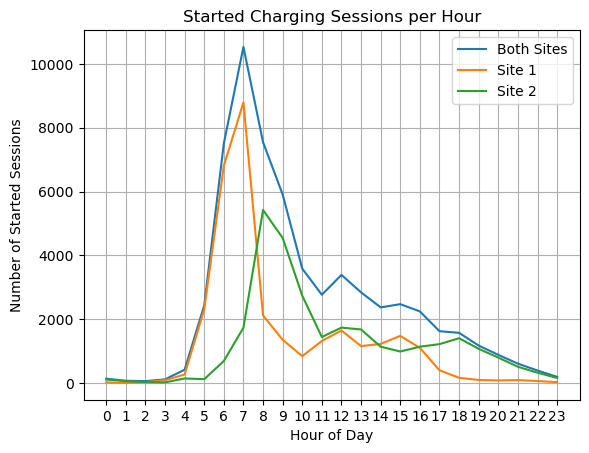

In [67]:
sessions_per_hour = (charging_data_hours.size())
sessions_per_hour_site1 = (site1_hours.size())
sessions_per_hour_site2 = (site2_hours.size())

plt.figure()
plt.plot(sessions_per_hour.index, sessions_per_hour.values, label="Both Sites")
plt.plot(sessions_per_hour_site1.index, sessions_per_hour_site1.values, label="Site 1")
plt.plot(sessions_per_hour_site2.index, sessions_per_hour_site2.values, label="Site 2")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Started Sessions")
plt.title("Started Charging Sessions per Hour")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.show()


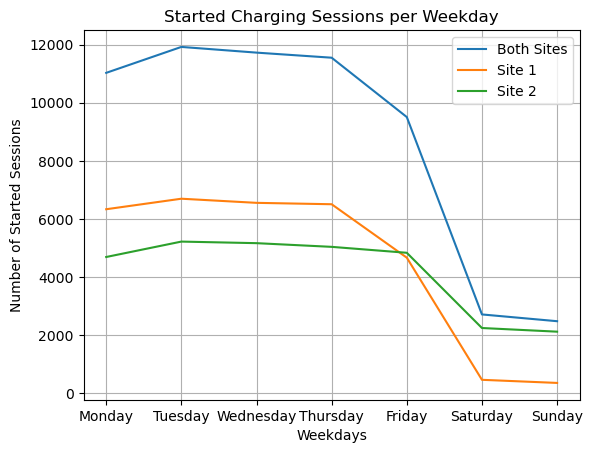

In [68]:
sessions_per_weekday = (charging_data_weekdays.size())
sessions_per_weekday_site1 = (site1_weekdays.size())
sessions_per_weekday_site2 = (site2_weekdays.size())

plt.figure()
plt.plot(sessions_per_weekday.index, sessions_per_weekday.values, label="Both Sites")
plt.plot(sessions_per_weekday_site1.index, sessions_per_weekday_site1.values, label="Site 1")
plt.plot(sessions_per_weekday_site2.index, sessions_per_weekday_site2.values, label="Site 2")
plt.xlabel("Weekdays")
plt.ylabel("Number of Started Sessions")
plt.title("Started Charging Sessions per Weekday")
plt.xticks(range(7), labels=weekdays)
plt.grid(True)
plt.legend()
plt.show()

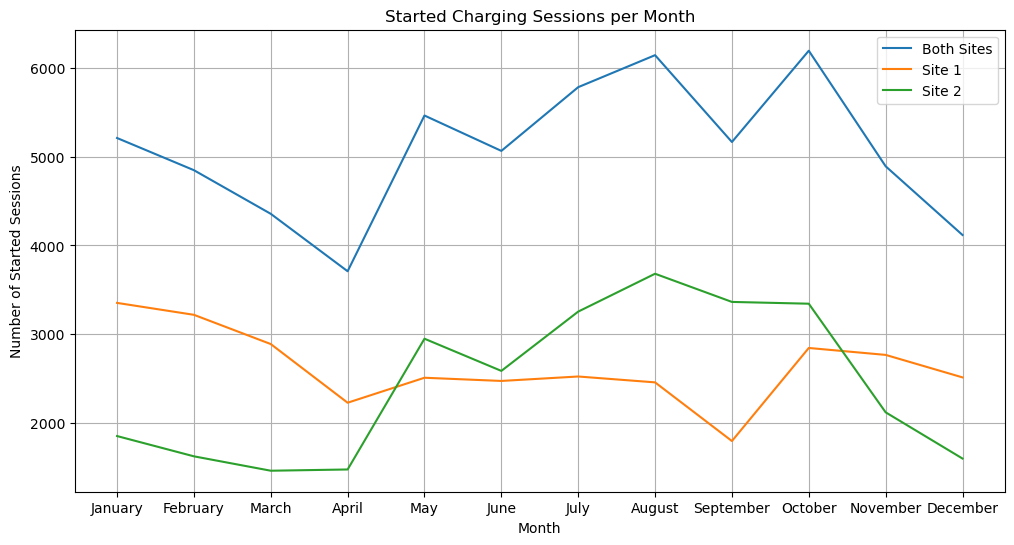

In [69]:
sessions_per_month = (charging_data_months.size())
sessions_per_month_site1 = (site1_months.size())
sessions_per_month_site2 = (site2_months.size())

plt.figure(figsize=(12,6))
plt.plot(sessions_per_month.index, sessions_per_month.values, label="Both Sites")
plt.plot(sessions_per_month_site1.index, sessions_per_month_site1.values, label="Site 1")
plt.plot(sessions_per_month_site2.index, sessions_per_month_site2.values, label="Site 2")
plt.xlabel("Month")
plt.ylabel("Number of Started Sessions")
plt.title("Started Charging Sessions per Month")
plt.xticks(range(1, 13), labels=months)
plt.grid(True)
plt.legend()
plt.show()

## Charging Efficiency

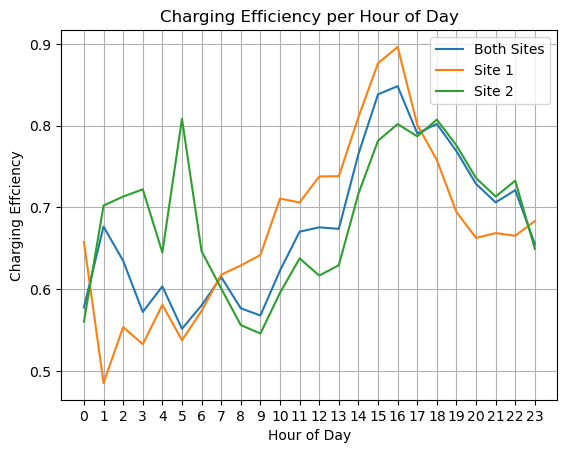

In [70]:
efficiency_per_hour = charging_data_hours["chargingEfficiency"].mean()
efficiency_per_hour_site1 = site1_hours["chargingEfficiency"].mean()
efficiency_per_hour_site2 = site2_hours["chargingEfficiency"].mean()

plt.figure()
plt.plot(efficiency_per_hour.index, efficiency_per_hour.values, label="Both Sites")
plt.plot(efficiency_per_hour_site1.index, efficiency_per_hour_site1.values, label="Site 1")
plt.plot(efficiency_per_hour_site2.index, efficiency_per_hour_site2.values, label="Site 2")
plt.xlabel("Hour of Day")
plt.ylabel("Charging Effciency")
plt.title("Charging Efficiency per Hour of Day")
plt.xticks(range(24))
plt.grid(True)
plt.legend()
plt.show()

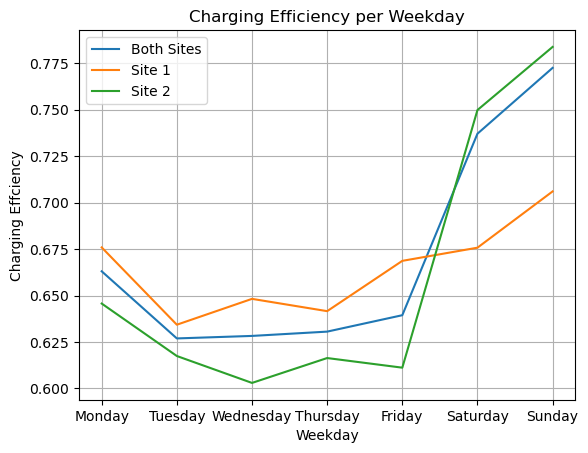

In [71]:
efficiency_per_weekday = charging_data_weekdays["chargingEfficiency"].mean()
efficiency_per_weekday_site1 = site1_weekdays["chargingEfficiency"].mean()
efficiency_per_weekday_site2 = site2_weekdays["chargingEfficiency"].mean()

plt.figure()
plt.plot(efficiency_per_weekday.index, efficiency_per_weekday.values, label="Both Sites")
plt.plot(efficiency_per_weekday_site1.index, efficiency_per_weekday_site1.values, label="Site 1")
plt.plot(efficiency_per_weekday_site2.index, efficiency_per_weekday_site2.values, label="Site 2")
plt.xlabel("Weekday")
plt.ylabel("Charging Effciency")
plt.title("Charging Efficiency per Weekday")
plt.xticks(range(7), labels=weekdays)
plt.grid(True)
plt.legend()
plt.show()

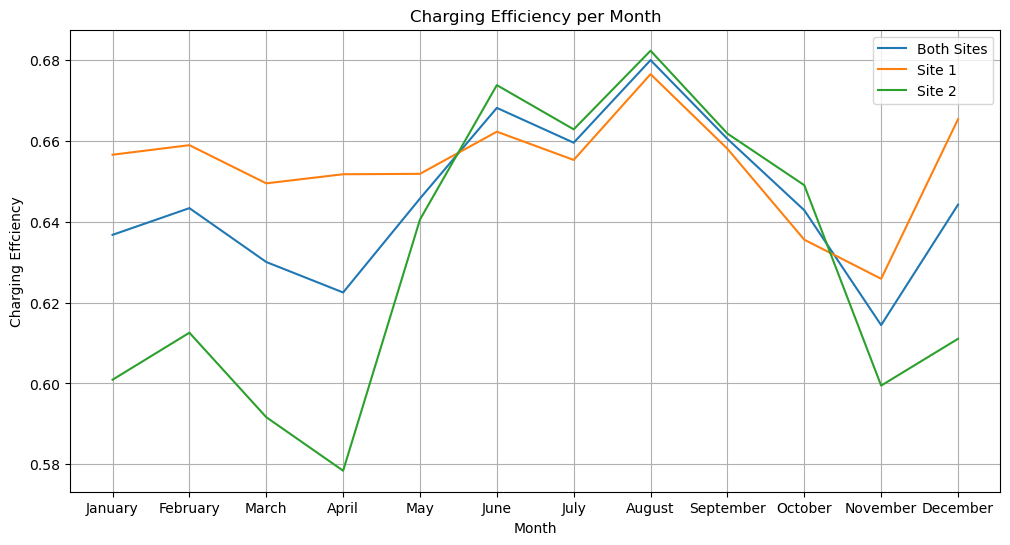

In [72]:
efficiency_per_month = charging_data_months["chargingEfficiency"].mean()
efficiency_per_month_site1 = site1_months["chargingEfficiency"].mean()
efficiency_per_month_site2 = site2_months["chargingEfficiency"].mean()

plt.figure(figsize=(12,6))
plt.plot(efficiency_per_month.index, efficiency_per_month.values, label="Both Sites")
plt.plot(efficiency_per_month_site1.index, efficiency_per_month_site1.values, label="Site 1")
plt.plot(efficiency_per_month_site2.index, efficiency_per_month_site2.values, label="Site 2")
plt.xlabel("Month")
plt.ylabel("Charging Effciency")
plt.title("Charging Efficiency per Month")
plt.xticks(range(1,13), labels=months)
plt.grid(True)
plt.legend()
plt.show()

## Charging Demand Fulfillment

Before we start visualizing this KPI we should first check which data is needed and how we can work with this data. In order to be able to check whether the charging demand was fulfilled we need kWhRequested (demand) and kWhDelivered (supply).
- kWhDelivered is a float column in the dataset and can therefore be used directly.
- kWhRequested is a float column that is contained in the userInputs list which is now still a simple object. Since userInputs can be updated we have to find out which entries are the last (and therefore relevant) ones. Intutively the last entry of the list should be the last updated one which is why we check whether the entries are chronologically sorted based on the modifiedAt column.

In [ ]:
def is_chronologically_sorted(user_input_list):
    # NaN is seen as correctly sorted
    if pd.isna(user_input_list):
        return True

    # empty list is seen as correctly sorted
    if not user_input_list:
        return True
    
    try:
        # check chronological sorting of filled lists
        dates = [entry["modifiedAt"] for entry in user_input_list if "modifiedAt" in entry]
        
        if len(dates) <= 1:
            return True
        
        return dates == sorted(dates)
    
    except Exception:
        return False

charging_data["userInput_sorted"] = charging_data["userInputs"].apply(is_chronologically_sorted)


In [74]:
charging_data[~charging_data["userInput_sorted"]]

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,timezone,...,userInputs,year,month,weekday,connectionHour,disconnectionHour,chargingDuration,connectionDuration,chargingEfficiency,userInput_sorted


In [75]:
charging_data[charging_data["userInput_sorted"]]

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,timezone,...,userInputs,year,month,weekday,connectionHour,disconnectionHour,chargingDuration,connectionDuration,chargingEfficiency,userInput_sorted
0,52871,5c36631ef9af8b4639a8e5bc,2018-10-08 15:44:47-07:00,2018-10-08 17:59:14-07:00,2018-10-08 17:56:20-07:00,10.208,1_1_193_825_2018-10-08 22:44:47.505042,1,AG-1F01,America/Los_Angeles,...,NaN,2018,10,0,15,17,2.192500,2.240833,0.978431,True
1,52886,5c366352f9af8b4639a8e5cb,2018-10-09 06:08:55-07:00,2018-10-09 15:03:56-07:00,2018-10-09 10:33:24-07:00,11.837,1_1_193_825_2018-10-09 13:08:55.279362,1,AG-1F01,America/Los_Angeles,...,NaN,2018,10,1,6,15,4.408056,8.916944,0.494346,True
2,52942,5c366352f9af8b4639a8e603,2018-10-09 15:26:40-07:00,2018-10-09 19:48:12-07:00,2018-10-09 19:28:29-07:00,12.034,1_1_193_825_2018-10-09 22:26:39.626134,1,AG-1F01,America/Los_Angeles,...,"[{'WhPerMile': 400, 'kWhRequested': 15.2, 'mil...",2018,10,1,15,19,4.030278,4.358889,0.924611,True
3,52958,5c36639ff9af8b4639a8e613,2018-10-10 06:15:02-07:00,2018-10-10 15:30:44-07:00,2018-10-10 10:56:11-07:00,11.985,1_1_193_825_2018-10-10 13:15:01.608497,1,AG-1F01,America/Los_Angeles,...,NaN,2018,10,2,6,15,4.685833,9.261667,0.505938,True
4,53015,5c36639ff9af8b4639a8e64c,2018-10-10 15:52:56-07:00,2018-10-10 17:34:00-07:00,2018-10-10 17:11:04-07:00,7.863,1_1_193_825_2018-10-10 22:52:55.607786,1,AG-1F01,America/Los_Angeles,...,NaN,2018,10,2,15,17,1.302222,1.684444,0.773087,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60917,24486,5cef242cf9af8b7096f0eee1,2019-05-13 12:43:12-07:00,2019-05-13 14:54:33-07:00,2019-05-13 13:46:37-07:00,2.308,2_39_139_567_2019-05-13 19:43:11.531976,2,CA-513,America/Los_Angeles,...,"[{'WhPerMile': 273, 'kWhRequested': 5.46, 'mil...",2019,5,0,12,14,1.056944,2.189167,0.482807,True
60918,25428,5d18029ef9af8b7fe5078422,2019-06-13 09:53:42-07:00,2019-06-13 10:35:12-07:00,2019-06-13 10:24:57-07:00,0.908,2_39_139_567_2019-06-13 16:53:42.369384,2,CA-513,America/Los_Angeles,...,NaN,2019,6,3,9,10,0.520833,0.691667,0.753012,True
60919,28029,5d954125f9af8b4500d3bc5b,2019-09-16 06:55:08-07:00,2019-09-16 08:34:27-07:00,2019-09-16 07:25:44-07:00,0.893,2_39_139_567_2019-09-16 13:55:08.397527,2,CA-513,America/Los_Angeles,...,NaN,2019,9,0,6,8,0.510000,1.655278,0.308105,True
60920,29514,5dd88bb1f9af8b7afc4cf5f1,2019-11-06 07:28:18-08:00,2019-11-06 08:41:56-08:00,2019-11-06 07:58:42-08:00,0.900,2_39_139_567_2019-11-06 15:28:18.090745,2,CA-513,America/Los_Angeles,...,NaN,2019,11,2,7,8,0.506667,1.227222,0.412856,True


We see that all userInputs are chronologically sorted which tells us that the last entry will be the relevant one for our KPI since we want to compare the requested kWh (current/last request) with the delivered kWh.  
Now we have to extract the kWhRequested column out of the userInputs list. Since it technically has to be a list (see assignment description) but is an object, it tells us that not all entries are lists. Therefore we have to check  datatypes and transform the entries into lists.

In [76]:
charging_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60922 entries, 0 to 60921
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   Unnamed: 0          60922 non-null  int64                              
 1   id                  60922 non-null  object                             
 2   connectionTime      60922 non-null  datetime64[ns, America/Los_Angeles]
 3   disconnectTime      60922 non-null  datetime64[ns, America/Los_Angeles]
 4   doneChargingTime    60922 non-null  datetime64[ns, America/Los_Angeles]
 5   kWhDelivered        60922 non-null  float64                            
 6   sessionID           60922 non-null  object                             
 7   siteID              60922 non-null  int64                              
 8   spaceID             60922 non-null  object                             
 9   timezone            60922 non-null  obj

In [ ]:
def extract_latest_kwh(user_input):
    # ignore NaN and floats
    if user_input is None or (isinstance(user_input, float) and np.isnan(user_input)):
        return np.nan

    # transform strings into lists
    if isinstance(user_input, str):
        try:
            user_input = ast.literal_eval(user_input)
        except:
            return np.nan

    # already a list
    if not isinstance(user_input, list) or len(user_input) == 0:
        return np.nan

    latest_entry = user_input[-1]

    # dictionary
    if not isinstance(latest_entry, dict):
        return np.nan

    return latest_entry.get("kWhRequested", np.nan)


charging_data["lastKWhRequested"] = charging_data["userInputs"].apply(extract_latest_kwh)

Now we check how the current kWhRequested gets extracted out of differently filled userInputs into their own column.

In [78]:
charging_data[["userInputs", "lastKWhRequested"]].head()

,userInputs,lastKWhRequested
0,NaN,NaN
1,NaN,NaN
2,"[{'WhPerMile': 400, 'kWhRequested': 15.2, 'mil...",15.2
3,NaN,NaN
4,NaN,NaN


In [79]:
charging_data[charging_data["lastKWhRequested"].notna()]

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,timezone,...,year,month,weekday,connectionHour,disconnectionHour,chargingDuration,connectionDuration,chargingEfficiency,userInput_sorted,lastKWhRequested
2,52942,5c366352f9af8b4639a8e603,2018-10-09 15:26:40-07:00,2018-10-09 19:48:12-07:00,2018-10-09 19:28:29-07:00,12.034,1_1_193_825_2018-10-09 22:26:39.626134,1,AG-1F01,America/Los_Angeles,...,2018,10,1,15,19,4.030278,4.358889,0.924611,True,15.200
7,53110,5c366417f9af8b4639a8e6ab,2018-10-12 10:07:47-07:00,2018-10-12 15:58:22-07:00,2018-10-12 14:46:28-07:00,14.289,1_1_193_825_2018-10-12 17:07:46.566136,1,AG-1F01,America/Los_Angeles,...,2018,10,4,10,15,4.644722,5.843056,0.794913,True,15.125
8,53137,5c36645ef9af8b4639a8e6c6,2018-10-15 06:46:28-07:00,2018-10-15 17:43:30-07:00,2018-10-15 09:03:25-07:00,6.457,1_1_193_825_2018-10-15 13:46:28.073298,1,AG-1F01,America/Los_Angeles,...,2018,10,0,6,17,2.282500,10.950556,0.208437,True,10.150
9,53212,5c3664aaf9af8b4639a8e711,2018-10-16 07:13:50-07:00,2018-10-16 15:03:42-07:00,2018-10-16 10:11:45-07:00,7.416,1_1_193_825_2018-10-16 14:13:49.883021,1,AG-1F01,America/Los_Angeles,...,2018,10,1,7,15,2.965278,7.831111,0.378654,True,16.000
10,53257,5c3664aaf9af8b4639a8e73e,2018-10-16 15:29:34-07:00,2018-10-16 20:30:34-07:00,2018-10-16 18:33:31-07:00,9.909,1_1_193_825_2018-10-16 22:29:34.302430,1,AG-1F01,America/Los_Angeles,...,2018,10,1,15,20,3.065833,5.016667,0.611130,True,21.250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60912,23360,5cc25127f9af8b2347da3e25,2019-04-09 11:30:12-07:00,2019-04-09 16:04:32-07:00,2019-04-09 14:18:28-07:00,8.766,2_39_139_567_2019-04-09 18:30:12.060969,2,CA-513,America/Los_Angeles,...,2019,4,1,11,16,2.804444,4.572222,0.613366,True,25.000
60913,23644,5cce2ea4f9af8b558e49f3dc,2019-04-17 12:59:35-07:00,2019-04-17 13:37:45-07:00,2019-04-17 13:37:36-07:00,2.089,2_39_139_567_2019-04-17 19:59:35.142904,2,CA-513,America/Los_Angeles,...,2019,4,2,12,13,0.633611,0.636111,0.996070,True,9.990
60914,23648,5cce2ea4f9af8b558e49f3e0,2019-04-17 14:33:58-07:00,2019-04-17 16:56:33-07:00,2019-04-17 16:47:29-07:00,14.393,2_39_139_567_2019-04-17 21:33:57.856025,2,CA-513,America/Los_Angeles,...,2019,4,2,14,16,2.225278,2.376389,0.936411,True,16.000
60917,24486,5cef242cf9af8b7096f0eee1,2019-05-13 12:43:12-07:00,2019-05-13 14:54:33-07:00,2019-05-13 13:46:37-07:00,2.308,2_39_139_567_2019-05-13 19:43:11.531976,2,CA-513,America/Los_Angeles,...,2019,5,0,12,14,1.056944,2.189167,0.482807,True,5.460


44637 out of 60922 rows in our dataset contain userInputs and can therefore be used for this KPI. We therefore already know that in 73.3% of all charging sessions the customer have requested kWh beforehand. Now we want to check whether it was possible to meet the demand.  
The results can show three different scenarios:
- the operator delivers exactly the amount of kWh that was requested
- the operator delivers more than requested (e.g. because roughly 27% of charging sessions did not request any kWh)
- the operator delivers less than requested (e.g. because customer have problems with estimating the amount of kWh needed or because charging stations are occupied and customer are only able to start charging later than expected)

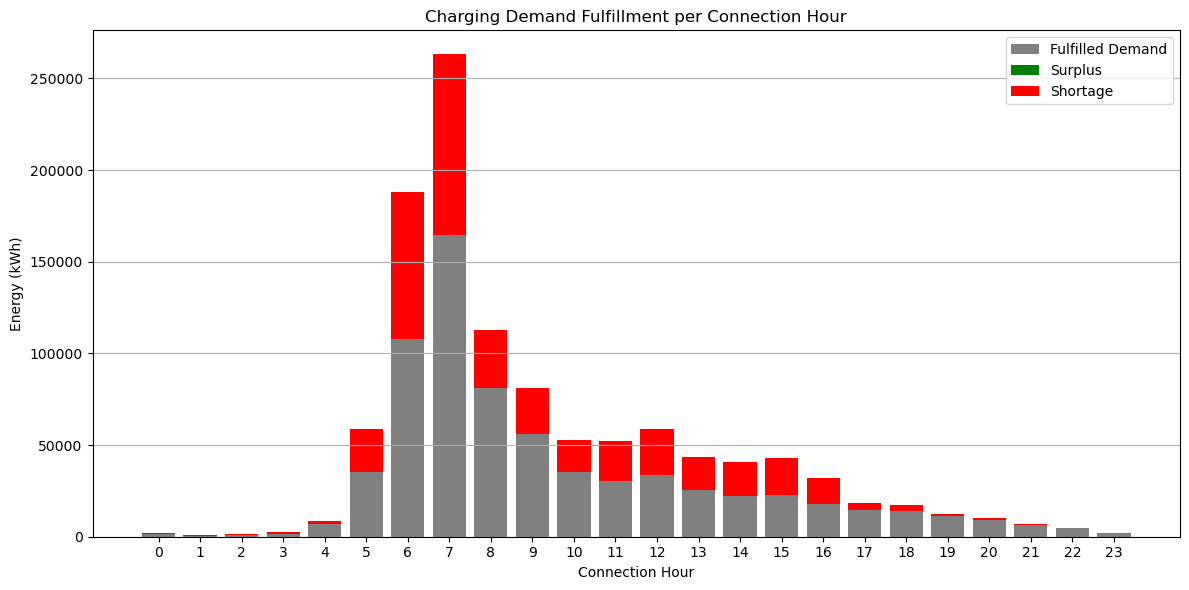

In [93]:
energy_hours = charging_data_hours[["lastKWhRequested", "kWhDelivered"]].sum()

# delivered > requested
energy_hours["surplus"] = (energy_hours["kWhDelivered"] - energy_hours["lastKWhRequested"]).clip(lower=0)

# delivered < requested
energy_hours["shortage"] = (energy_hours["lastKWhRequested"] - energy_hours["kWhDelivered"]).clip(lower=0)

# fulfilled demand
energy_hours["fulfilled"] = energy_hours["lastKWhRequested"] - energy_hours["shortage"]

hours = energy_hours.index

plt.figure(figsize=(12, 6))

# grey = fulfilled demand
plt.bar(hours, energy_hours["fulfilled"], color="grey", label="Fulfilled Demand")

# green = surplus
plt.bar(
    hours,
    energy_hours["surplus"],
    bottom=energy_hours["fulfilled"],
    color="green",
    label="Surplus"
)

# red = shortage
plt.bar(
    hours,
    energy_hours["shortage"],
    bottom=energy_hours["fulfilled"],
    color="red",
    label="Shortage"
)

plt.xlabel("Connection Hour")
plt.ylabel("Energy (kWh)")
plt.title("Charging Demand Fulfillment per Connection Hour")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()


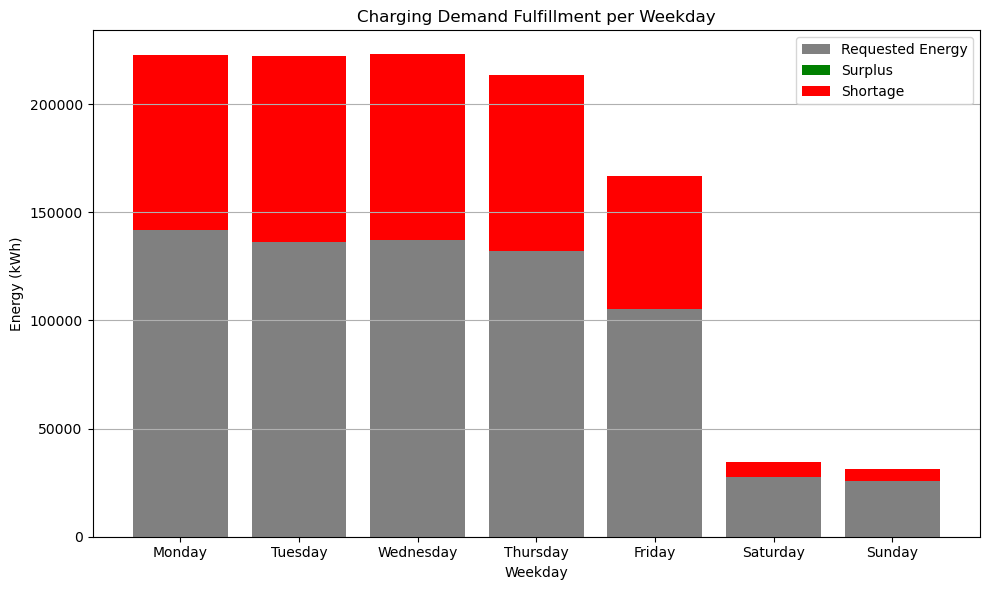

In [94]:
weekday_energy = (charging_data_weekdays[["lastKWhRequested", "kWhDelivered"]].sum())

# delivered > requested
weekday_energy["surplus"] = (weekday_energy["kWhDelivered"] - weekday_energy["lastKWhRequested"]).clip(lower=0)

# delivered < requested
weekday_energy["shortage"] = (weekday_energy["lastKWhRequested"] - weekday_energy["kWhDelivered"]).clip(lower=0)

# fulfilled demand
weekday_energy["fulfilled"] = weekday_energy["lastKWhRequested"] - weekday_energy["shortage"]


plt.figure(figsize=(10, 6))

# grey = fulfilled demand
plt.bar(weekdays, weekday_energy["fulfilled"], color="grey", label="Requested Energy")

# green = surplus
plt.bar(
    weekdays,
    weekday_energy["surplus"],
    bottom=weekday_energy["fulfilled"],
    color="green",
    label="Surplus"
)

# red = shortage
plt.bar(
    weekdays,
    weekday_energy["shortage"],
    bottom=weekday_energy["fulfilled"],
    color="red",
    label="Shortage"
)

plt.xlabel("Weekday")
plt.ylabel("Energy (kWh)")
plt.title("Charging Demand Fulfillment per Weekday")
plt.xticks(ticks=range(7), labels=weekdays)
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()



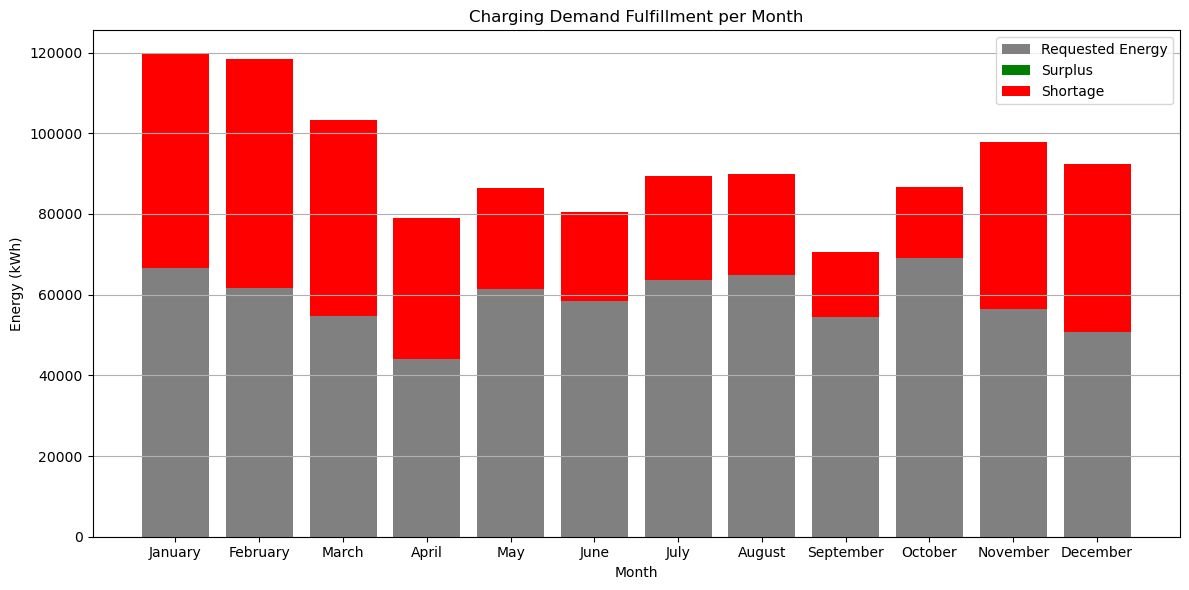

In [97]:
monthly_energy = (charging_data_months[["lastKWhRequested", "kWhDelivered"]].sum())

# delivered > requested
monthly_energy["surplus"] = (monthly_energy["kWhDelivered"] - monthly_energy["lastKWhRequested"]).clip(lower=0)

# delivered < requested
monthly_energy["shortage"] = (monthly_energy["lastKWhRequested"] - monthly_energy["kWhDelivered"]).clip(lower=0)

# fulfilled demand
monthly_energy["fulfilled"] = monthly_energy["lastKWhRequested"] - monthly_energy["shortage"]

x = range(1, 13)

plt.figure(figsize=(12, 6))

# grey = fulfilled demand
plt.bar(x, monthly_energy["fulfilled"], color="grey", label="Requested Energy")

# green = surplus
plt.bar(
    x,
    monthly_energy["surplus"],
    bottom=monthly_energy["fulfilled"],
    color="green",
    label="Surplus"
)

# red = shortage
plt.bar(
    x,
    monthly_energy["shortage"],
    bottom=monthly_energy["fulfilled"],
    color="red",
    label="Shortage"
)

plt.xlabel("Month")
plt.ylabel("Energy (kWh)")
plt.title("Charging Demand Fulfillment per Month")
plt.xticks(x, labels=months)
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()


TODO: Überlegen ob Unterscheidung der Sites hier Sinn macht